In [9]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
from domain import *
import geopandas as gpd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, MultiPolygon
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
from matplotlib.patches import Patch

# Box definition of the 5 subregions we defined (in red)

In [4]:
# elevation grid (DOI: 10.25921/fd45-gt74) based on ERA5 grid
elev = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/gmted/gmted_on_era5_MA.nc')['elevation']

In [5]:
#CH : Central Himalaya
dsCH=field_dom(elev,'CH') # elevation only on 'CH' domain
dsSH_CH=dsCH
LONS_CH,LATS_CH=dsCH.longitude,dsCH.latitude # longitude and latitude of 'CH' domain

#HK : Hindu Kush
dsHK=field_dom(elev,'HK')
dsSH_HK=dsHK
LONS_HK,LATS_HK=dsHK.longitude,dsHK.latitude

#TP : Tibetan Plateau
dsTP=field_dom(elev,'TP')
dsSH_TP=dsTP
LONS_TP,LATS_TP=dsTP.longitude,dsTP.latitude

#SEH : Southeastern Himalaya
dsSEH=field_dom(elev,'SEH')
dsSH_SEH=dsSEH
LONS_SEH,LATS_SEH=dsSEH.longitude,dsSEH.latitude

#SL : Spiti-Lahaul-Karakoram
dsSL=field_dom(elev,'SL')
dsSH_SL=dsSL
LONS_SL,LATS_SL=dsSL.longitude,dsSL.latitude

In [6]:
# Compute rectangle (box) coordinates to make the red boxes for the plot

CH_box = [LONS_CH.min().item(), LONS_CH.max().item(),
             LATS_CH.min().item(), LATS_CH.max().item()] # [min_lon, max_lon, min_lat, max_lat]

HK_box = [LONS_HK.min().item(), LONS_HK.max().item(),
             LATS_HK.min().item(), LATS_HK.max().item()]

TP_box = [LONS_TP.min().item(), LONS_TP.max().item(),
             LATS_TP.min().item(), LATS_TP.max().item()]

SEH_box = [LONS_SEH.min().item(), LONS_SEH.max().item(),
             LATS_SEH.min().item(), LATS_SEH.max().item()]

SL_box = [LONS_SL.min().item(), LONS_SL.max().item(),
             LATS_SL.min().item(), LATS_SL.max().item()]

# Subregions with glacier evolution data (in green)

For more details : shapefile created and saved in '/home/bricej/MyPythonLibrary/StageM2_IVT/papier/himap_grouped_regions_hugonnet'

In [7]:
# shapefile with the polygons of the suberegions
dg = gpd.read_file('/bettik/PROJECTS/pr-regional-climate/bricej/HIMAP_grouped_regions/himap_grouped_regions.shp')

# Final plot with all the suberegions used in the study

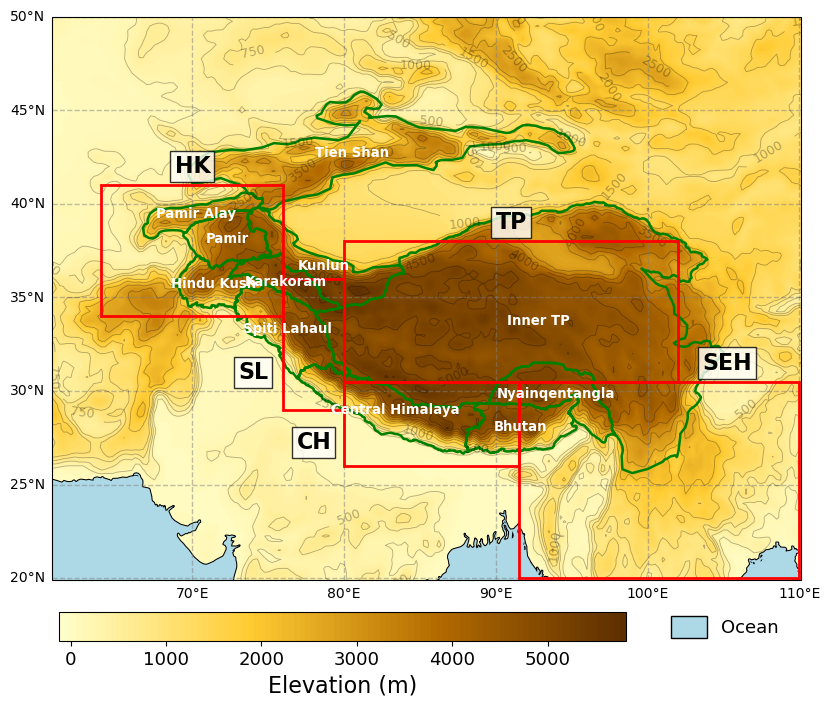

In [16]:
# colors for elevation colorgrading (only on land)
cmap = mcolors.LinearSegmentedColormap.from_list(
    "yellow_brown",
    ["#ffffcc",  # jaune très clair
     "#ffcc33",  # jaune doré
     "#b36b00",  # brun orangé
     "#5c2e00"]  # brun foncé
)

# figure
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# plot les contours des polygones du shapefile en vert (glacier evolution data regions)
dg.plot(ax=ax,facecolor="none",edgecolor="green",linewidth=1.8, zorder = 5)

ax.coastlines(linewidth=1.5) # coast lines
ax.add_feature(cfeature.OCEAN, facecolor="lightblue", zorder=2) # ocean in one color (lightblue)
ax.add_feature(cfeature.LAND,facecolor="none", zorder=2) # no color for land (colorgrading next)

# elevation colorgrading 
cf = ax.contourf(elev.longitude,elev.latitude,elev,levels=100,cmap=cmap,transform=ccrs.PlateCarree(),zorder=1)

#Courbes de niveau
SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[250,500,750,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000],
                colors="black",linewidths=0.6,alpha=0.3,transform=ccrs.PlateCarree(), zorder=3)
ax.clabel(SH, inline=True, fontsize=9, fmt="%d") # label des courbes de niveau

# Labels des régions en vert 
for idx, row in dg.iterrows():
    centroid = row.geometry.centroid # centroïde de la région : (x,y)=(lon,lat)
    ax.text(centroid.x,centroid.y, # coordonnées du centroïd
        row["Primary_ID"],fontsize=9.5,fontweight='bold',ha='center',va='center',color='white', # text parameters
        transform=ccrs.PlateCarree(),zorder=8)

# color bar for elevation colorgrading
cbar = fig.colorbar(cf,ax=ax,orientation="horizontal",fraction=0.046,pad=0.04) # colorbar
pos = cbar.ax.get_position() # position de la colorbar
cbar.ax.set_position([
    pos.x0 - 0.07,  # gauche
    pos.y0 - 0.01,  # bas
    pos.width,pos.height])
cbar.set_label("Elevation (m)", fontsize=16)
cbar.set_ticks(list(range(0, 6000, 1000))) # forcer les ticks tous les 1000 de 0 à 6000 m
cbar.ax.tick_params(labelsize=13)

# Légende de l'océan à droite de la colorbar
ocean_patch = Patch(facecolor="lightblue", edgecolor="black", label="Ocean")
cbar.ax.legend(handles=[ocean_patch],loc="center left",
               bbox_to_anchor=(1.05, 0.5), # à droite de la colorbar
               handlelength=2,handleheight=1.5,fontsize=13,frameon=False)

# Add red rectangles for the 5 subdomains we defined
for box in [CH_box, HK_box, TP_box, SEH_box, SL_box]:
    rect = Rectangle((box[0], box[2]), box[1]-box[0], box[3]-box[2],
                     linewidth=2, edgecolor='red', facecolor='none', transform=ccrs.PlateCarree(), zorder=6)
    ax.add_patch(rect)

#Add text zone for labels of the red boxes
latS, latN, lonW, lonE = coord_domain('HK') # [min_lat, max_lat, min_lon, max_lon]
ax.text((lonW + lonE) / 2, latN + 1, "HK",horizontalalignment='center',verticalalignment='center',fontsize=16,fontweight='bold',
        color='black',transform=ccrs.PlateCarree(),zorder=7,bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=3))
latS, latN, lonW, lonE = coord_domain('TP')
ax.text((lonW + lonE) / 2, latN + 1, "TP",horizontalalignment='center',verticalalignment='center',fontsize=16,fontweight='bold',
        color='black',transform=ccrs.PlateCarree(),zorder=7,bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=3))
latS, latN, lonW, lonE = coord_domain('CH')
ax.text(lonW - 2,(latS + latN) / 2 - 1, "CH",horizontalalignment='center',verticalalignment='center',fontsize=16,fontweight='bold',
        color='black',transform=ccrs.PlateCarree(),zorder=7,bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=3))
latS, latN, lonW, lonE = coord_domain('SEH')
ax.text((lonW + lonE) / 2 + 4.5, latN + 1, "SEH",horizontalalignment='center',verticalalignment='center',fontsize=16,fontweight='bold',
        color='black',transform=ccrs.PlateCarree(),zorder=7,bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=3))
latS, latN, lonW, lonE = coord_domain('SL')
ax.text(lonW - 2,(latS + latN) / 2 - 1.5, "SL",horizontalalignment='center',verticalalignment='center',fontsize=16,fontweight='bold',
        color='black',transform=ccrs.PlateCarree(),zorder=7,bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=3))

# limites de la figure
bounds = dg.total_bounds #[minx, miny, maxx, maxy]
ax.set_extent([bounds[0]-6, bounds[2]+5.1, bounds[1]-5.7, bounds[3]+4],crs=ccrs.PlateCarree())

# grille lat lon
gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

plt.show()

Figure 2. High Mountain Asia elevation map and subregional division: red boxes represent the subregions we defined in this study: Hindu Kush–Pamir (HK), Spiti–Lahaul–Karakoram (SL), Tibetan Plateau (TP), Central Himalaya (CH), Southeastern Himalaya (SEH). Green outlined regions are based on the HIMAP regions described in Bolch et al. (2019) (Appendix Fig. 1) and are subsequently grouped following the classification proposed by Brun et al. (2017).  Elevation (shading) is computed from NOAA National Centers for Environmental Information, 2022 : ETOPO 2022 15 Arc-Second Global Relief Model. (DOI: 10.25921/fd45-gt74, accessed in February 2026) and  regridded to the ERA5 grid at 0.25° x 0.25° resolution.